In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set standard plotting style
plt.style.use('ggplot')
sns.set_palette("muted")

# ---------------------------------------------------------
# Define input pairs here. 
# Add new dictionaries to the list for future model evaluations.
# ---------------------------------------------------------
input_pairs = [
    # {
    #     "model_name": "DeepseekV4Flash (Deployability)",
    #     "result_file": "result/iacgod/DeepseekV4Flash_deployability.csv",
    #     "intent_file": "result/iacgod/Intent_DSV4_CFN_Dep.csv"
    # },
    # # Future example:
    # {
    #     "model_name": "DeepseekV4Flash (Security)",
    #     "result_file": "result/iacgod/DeepseekV4Flash_security.csv",
    #     "intent_file": "result/iacgod/Intent_DSV4_CFN_Sec.csv"
    # },
    {
        "model_name": "No Planner",
        "result_file": "result/iacgod/DeepseekV4Flash_sec_ablation_no_planner.csv",
        "intent_file": "result/iacgod/Intent_DSV4_Ablation_No_Planner.csv"
    },
    {
        "model_name": "No HyDE",
        "result_file": "result/iacgod/DeepseekV4Flash_sec_ablation_no_hyde.csv",
        "intent_file": "result/iacgod/Intent_DSV4_Ablation_No_HyDE.csv"
    },
    {
        "model_name": "No Remediation",
        "result_file": "result/iacgod/DeepseekV4Flash_sec_ablation_no_remediation.csv",
        "intent_file": "result/iacgod/Intent_DSV4_Ablation_No_Remediator.csv"
    }
]

In [2]:
merged_dataframes = {}

for pair in input_pairs:
    model = pair["model_name"]
    res_df = pd.read_csv(pair["result_file"])
    intent_df = pd.read_csv(pair["intent_file"])
    
    # Merge based on row_number (using left join to keep base records)
    # Using suffixes to prevent column name collisions if both CSVs share generic names
    merged_df = pd.merge(res_df, intent_df, on="row_number", how="left", suffixes=("", "_intent"))
    
    # Calculate Intent Pass Rate: total_passed / (total_passed + total_failed)
    total_checks = merged_df["total_passed"] + merged_df["total_failed"]
    
    # Use np.where to safely avoid Division By Zero if a template had 0 checks
    merged_df["Intent Pass Rate (%)"] = np.where(
        total_checks > 0, 
        (merged_df["total_passed"] / total_checks) * 100, 
        np.nan
    )
    
    merged_dataframes[model] = merged_df
    print(f"Successfully merged {len(merged_df)} rows and calculated Intent Pass Rate for {model}.")

Successfully merged 15 rows and calculated Intent Pass Rate for No Planner.
Successfully merged 15 rows and calculated Intent Pass Rate for No HyDE.
Successfully merged 15 rows and calculated Intent Pass Rate for No Remediation.


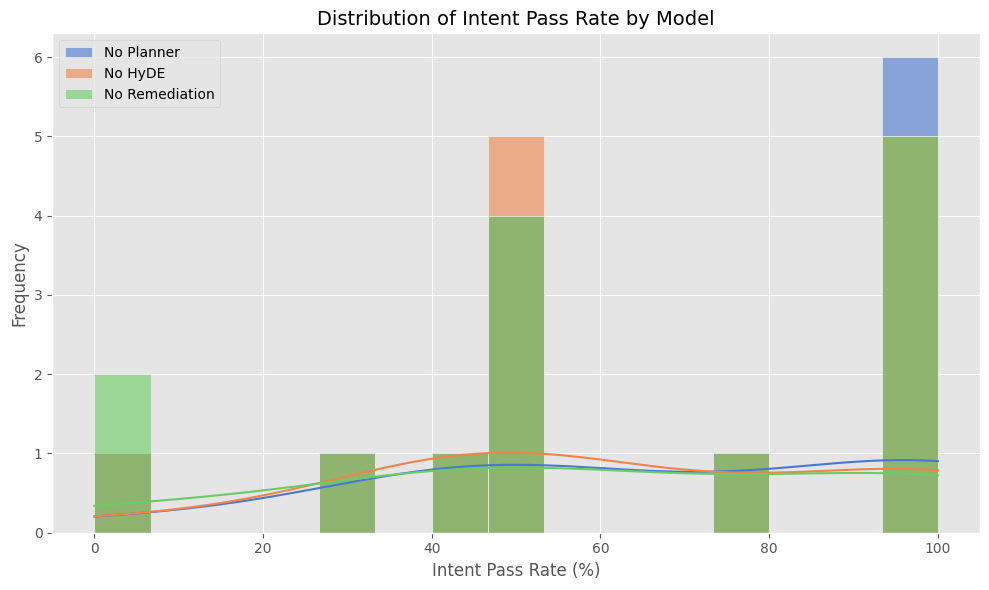

In [3]:
plt.figure(figsize=(10, 6))

for model_name, df in merged_dataframes.items():
    # Filter out NaNs where no intent checks were performed
    valid_rates = df["Intent Pass Rate (%)"].dropna()
    sns.histplot(valid_rates, bins=15, kde=True, label=model_name, alpha=0.6)
    
plt.title("Distribution of Intent Pass Rate by Model", fontsize=14)
plt.xlabel("Intent Pass Rate (%)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

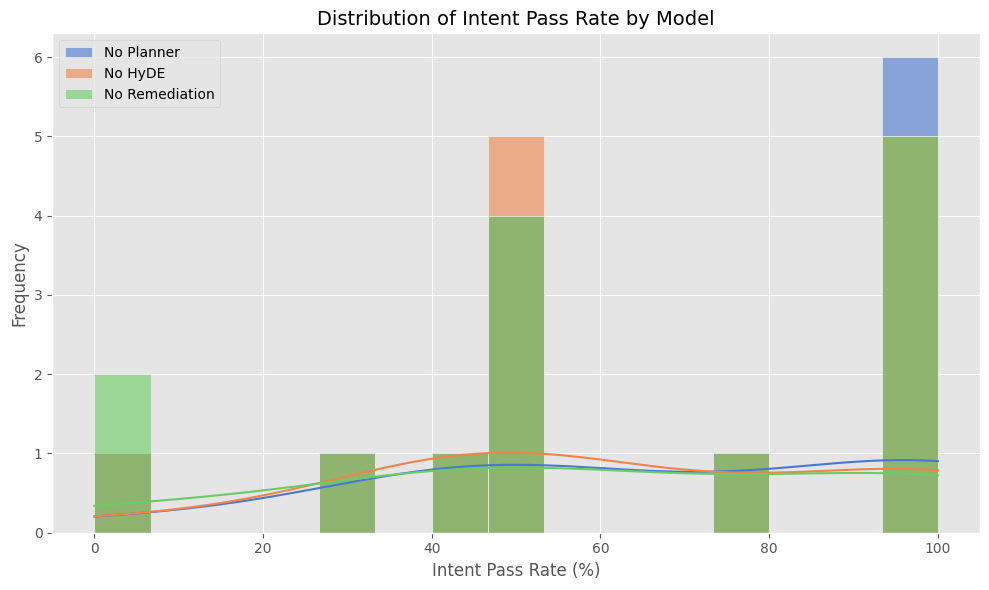

In [4]:
plt.figure(figsize=(10, 6))

for model_name, df in merged_dataframes.items():
    # Filter out NaNs where no intent checks were performed
    valid_rates = df["Intent Pass Rate (%)"].dropna()
    sns.histplot(valid_rates, bins=15, kde=True, label=model_name, alpha=0.6)
    
plt.title("Distribution of Intent Pass Rate by Model", fontsize=14)
plt.xlabel("Intent Pass Rate (%)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_99835/4229087869.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=avg_intent_df, x="Model", y="Average Intent Pass Rate (%)", palette="Set2")


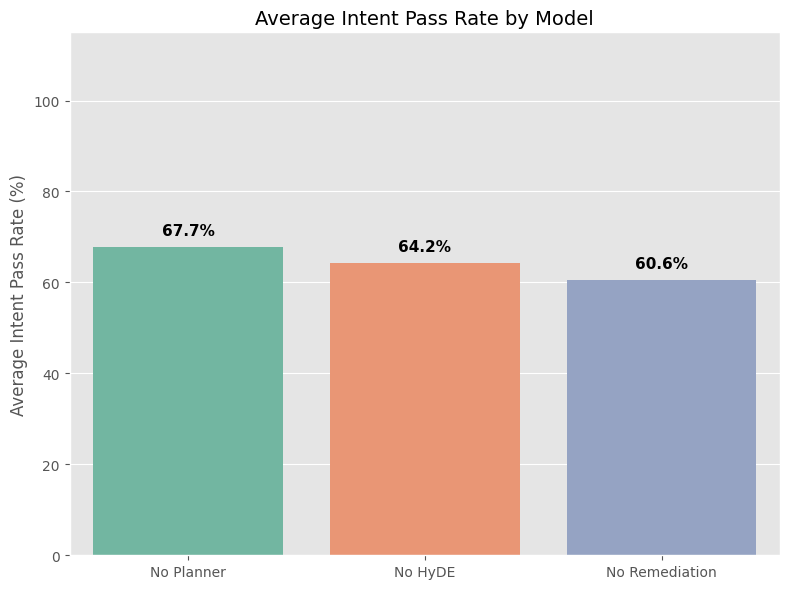

In [5]:
# %%
# Calculate and visualize the average Intent Pass Rate per model
avg_intent_data = []

for model_name, df in merged_dataframes.items():
    if "Intent Pass Rate (%)" in df.columns:
        # Calculate the mean, ignoring NaNs automatically
        avg_rate = df["Intent Pass Rate (%)"].mean()
        avg_intent_data.append({
            "Model": model_name,
            "Average Intent Pass Rate (%)": avg_rate
        })

if avg_intent_data:
    avg_intent_df = pd.DataFrame(avg_intent_data)
    
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(data=avg_intent_df, x="Model", y="Average Intent Pass Rate (%)", palette="Set2")
    
    plt.title("Average Intent Pass Rate by Model", fontsize=14)
    plt.ylabel("Average Intent Pass Rate (%)", fontsize=12)
    plt.xlabel("")
    plt.ylim(0, 115) # Give headroom for data labels
    
    # Add percentage labels to the top of each bar
    for p in ax.patches:
        height = p.get_height()
        if pd.notna(height) and height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2., 
                height + 2, 
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=11, 
                fontweight='bold'
            )
            
    plt.tight_layout()
    plt.show()
else:
    print("No Intent Pass Rate data available to calculate averages.")